# 05 — Additional Visualizations
Extra charts to complement EDA and model analysis.

In [1]:
# Setup
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import RAW_DIR
from src.visualize import save_current_fig
sns.set_context('talk')

In [2]:
df = pd.read_csv(RAW_DIR / 'ogun_weather.csv', parse_dates=[0], index_col=0)
df.head()

,temperature_c,humidity_pct,wind_speed_mps,precipitation_mm,surface_pressure_hpa
date,,,,,
2015-01-01 00:00:00+01:00,28.013043,53.521739,5.821739,0.0,10.001043
2015-01-02 00:00:00+01:00,27.583333,66.708333,5.304167,0.0,10.008292
2015-01-03 00:00:00+01:00,28.266667,62.791667,5.458333,0.0,10.021000
2015-01-04 00:00:00+01:00,27.716667,44.041667,6.500000,0.0,10.026333
2015-01-05 00:00:00+01:00,26.291667,28.291667,6.079167,0.0,10.018958


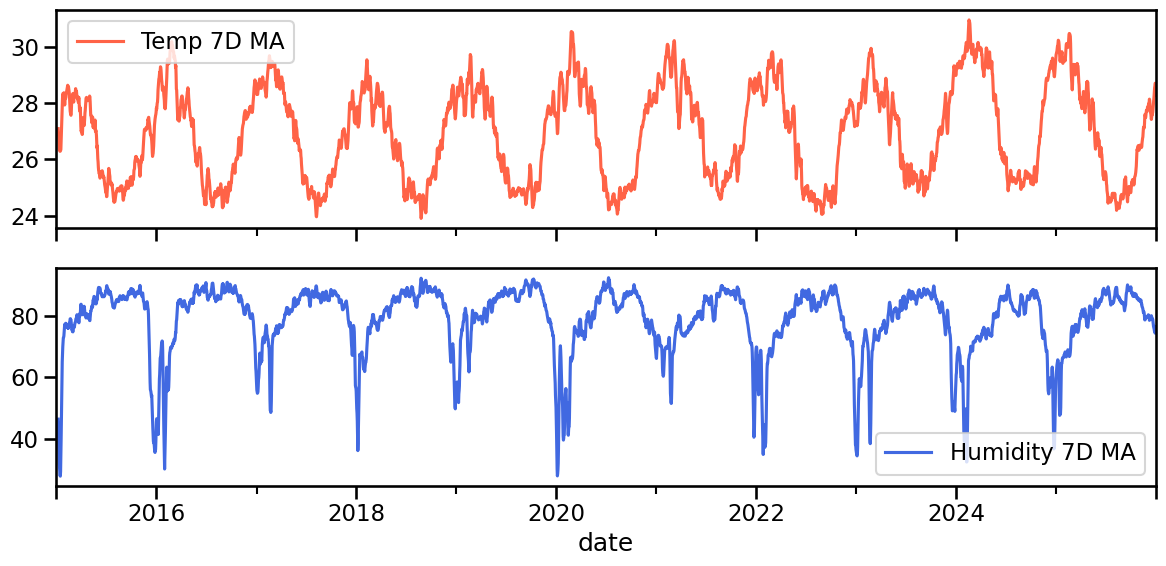

In [3]:
# Rolling averages for temperature and humidity
fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
df['temperature_c'].rolling(7).mean().plot(ax=ax[0], color='tomato', label='Temp 7D MA')
ax[0].legend()
df['humidity_pct'].rolling(7).mean().plot(ax=ax[1], color='royalblue', label='Humidity 7D MA')
ax[1].legend()
save_current_fig('rolling_avgs.png')
plt.show()

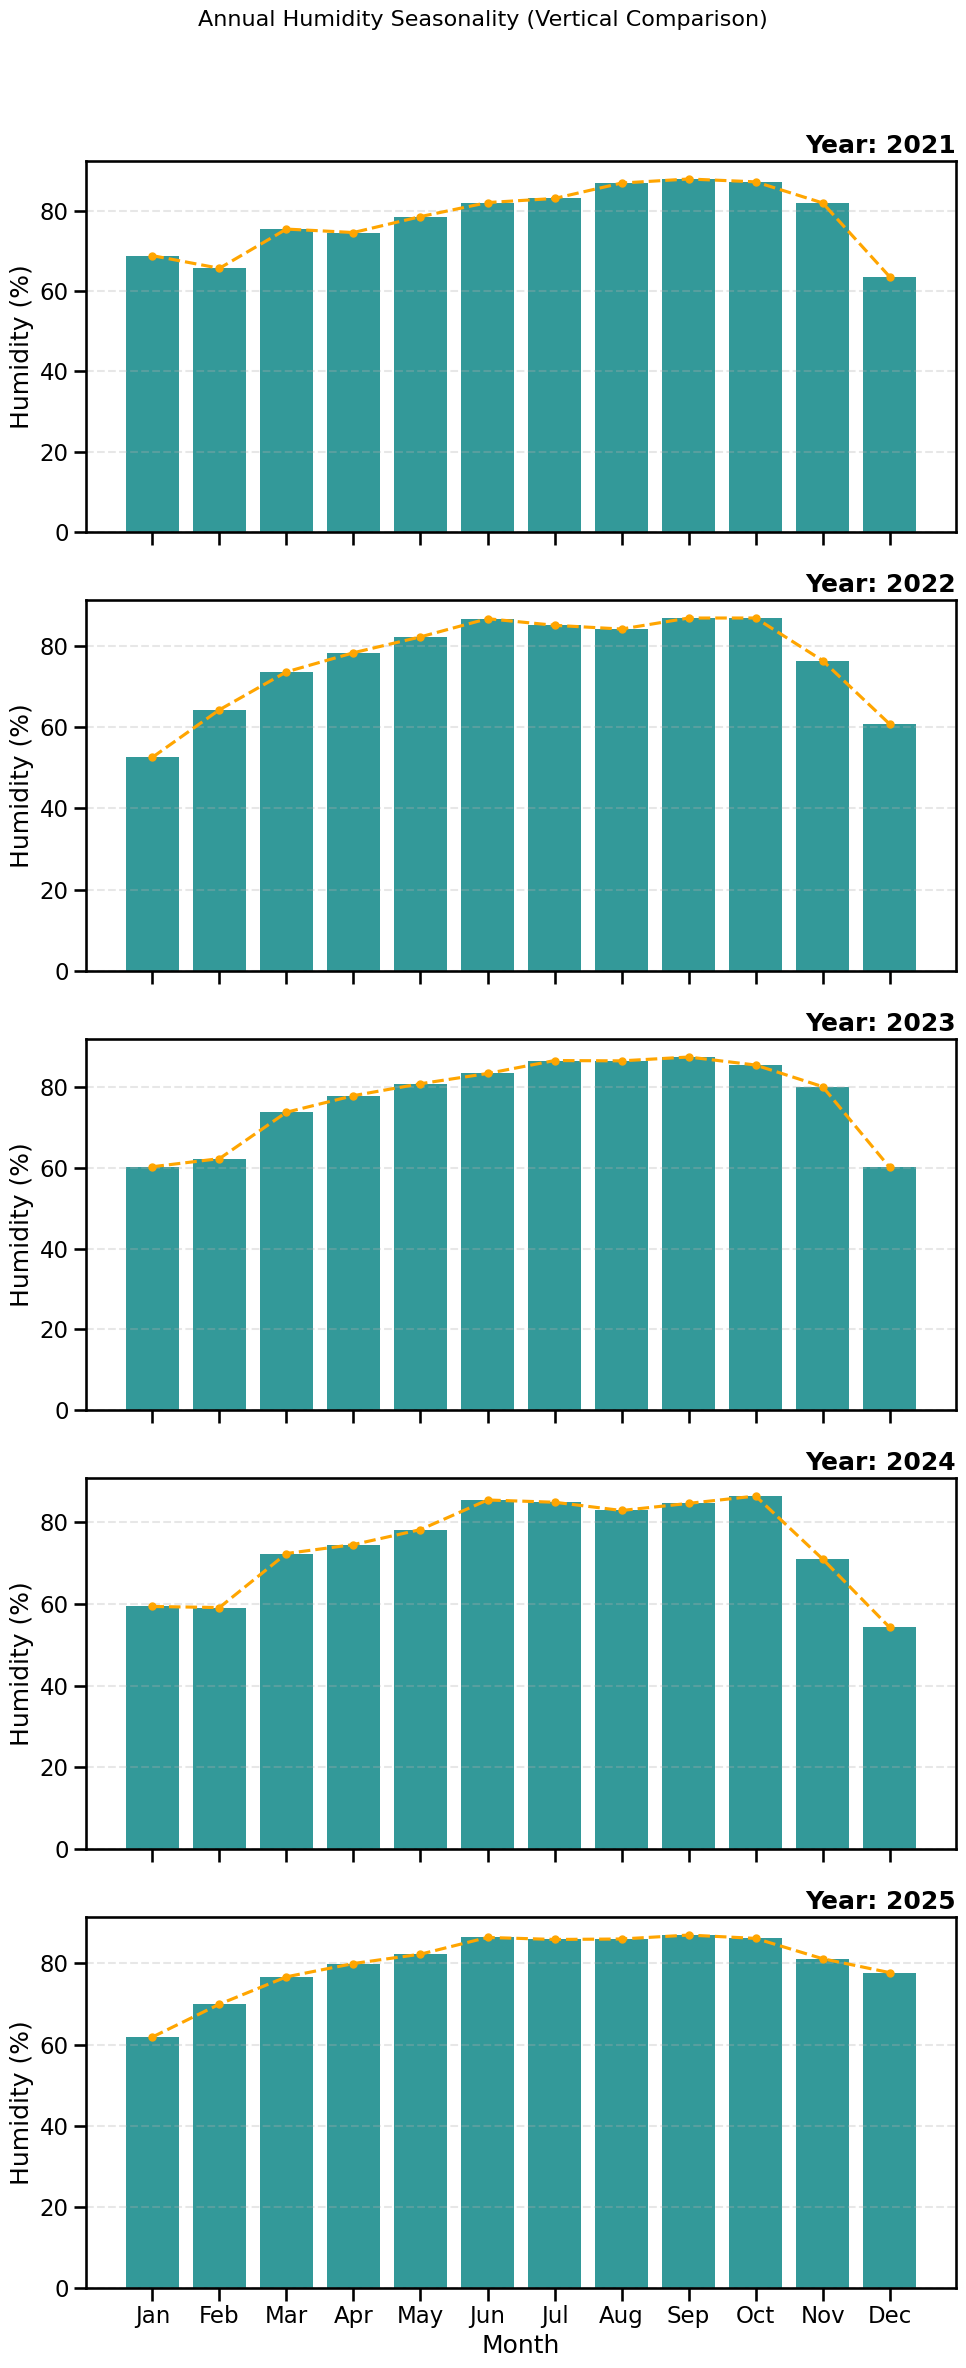

In [ ]:

# 1. Setup years
df['year'] = df.index.year
df['month'] = df.index.month
years = sorted(df['year'].unique())[-5:]  # Last 5 years

fig, axes = plt.subplots(len(years), 1, figsize=(10, 5 * len(years)), sharex=True, squeeze=False)
axes = axes.flatten()

for i, year in enumerate(years):
    data = df[df['year'] == year]
    monthly_humidity = data.groupby('month')['humidity_pct'].mean()
    monthly_humidity = monthly_humidity.reindex(range(1, 13), fill_value=0)

    axes[i].bar(monthly_humidity.index, monthly_humidity.values, color='teal', alpha=0.8)
    axes[i].set_title(f'Year: {year}', loc='right', fontweight='bold')
    axes[i].set_ylabel('Humidity (%)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    axes[i].plot(monthly_humidity.index, monthly_humidity.values, color='orange',
                 linestyle='--', marker='o', markersize=5)

    if i == len(years) - 1:
        axes[i].set_xticks(range(1, 13))
        axes[i].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
        axes[i].set_xlabel('Month')

fig.suptitle('Annual Humidity Seasonality (Vertical Comparison)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
save_current_fig('annual_humidity_seasonality.png')
plt.show()


In [5]:
df.shape

(4018, 7)

## Deeper Trends and Extremes

This section adds additional plots to surface long-term patterns, anomalies, and extreme events.

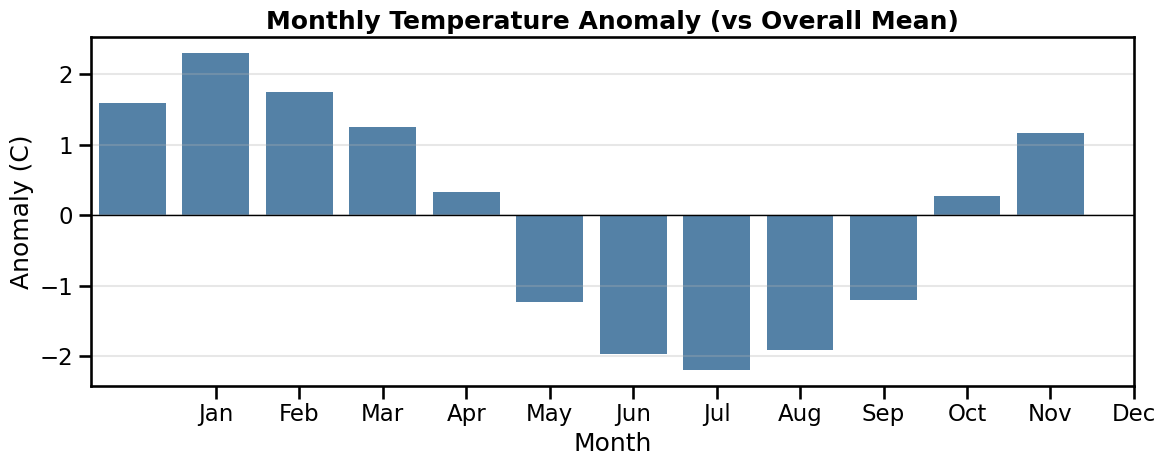

In [7]:
# Ensure time fields exist
df = df.sort_index()
df['year'] = df.index.year
df['month'] = df.index.month

# 1) Monthly temperature anomaly (deviation from overall mean)
overall_temp_mean = df['temperature_c'].mean()
monthly_temp_mean = df.groupby('month')['temperature_c'].mean()
temp_anomaly = monthly_temp_mean - overall_temp_mean

plt.figure(figsize=(12, 5))
sns.barplot(x=temp_anomaly.index, y=temp_anomaly.values, color='steelblue')
plt.axhline(0, color='black', linewidth=1)
plt.title('Monthly Temperature Anomaly (vs Overall Mean)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Anomaly (C)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y', alpha=0.3)
save_current_fig('monthly_temperature_anomaly.png')
plt.show()


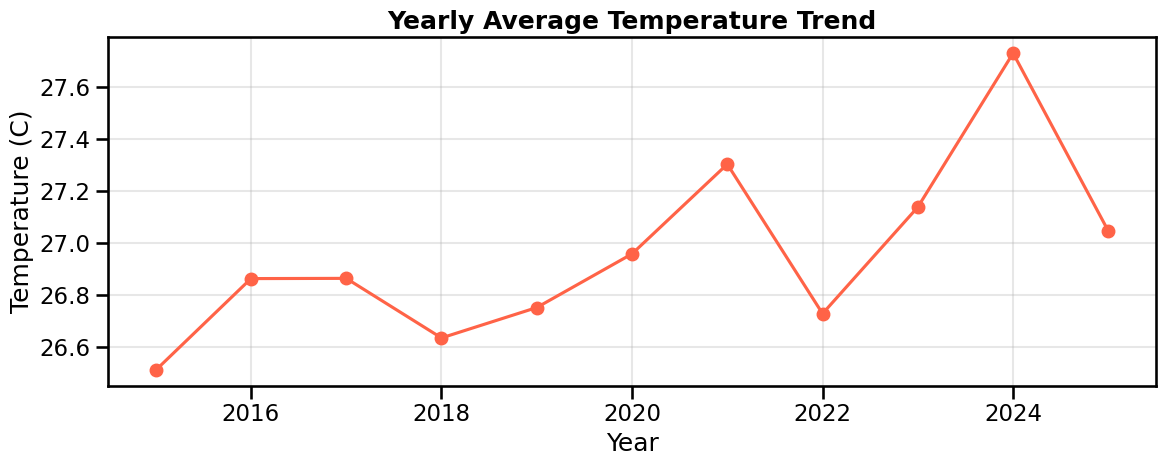

In [8]:

# 2) Yearly average temperature trend
yearly_temp = df.groupby('year')['temperature_c'].mean()
plt.figure(figsize=(12, 5))
plt.plot(yearly_temp.index, yearly_temp.values, marker='o', color='tomato')
plt.title('Yearly Average Temperature Trend', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Temperature (C)')
plt.grid(alpha=0.3)
save_current_fig('yearly_avg_temperature_trend.png')
plt.show()


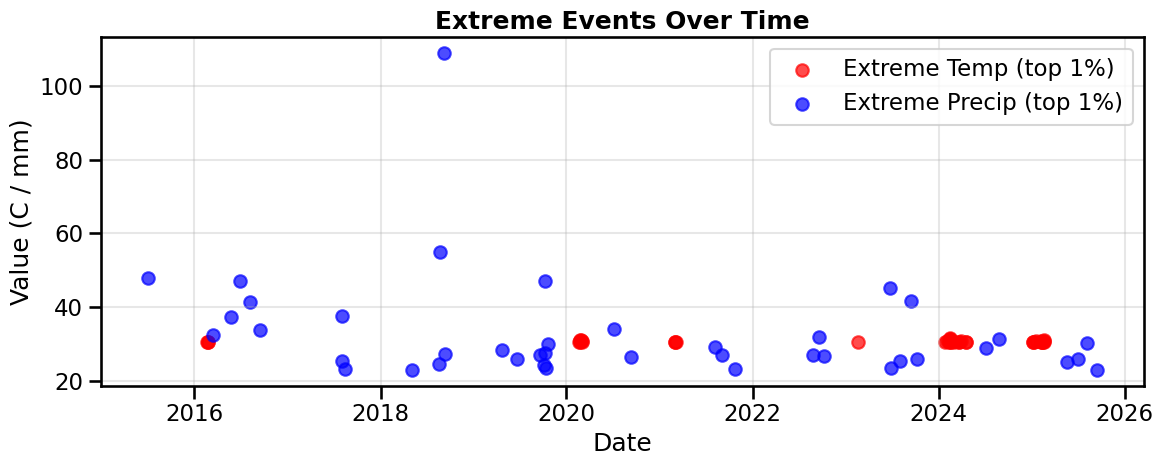

In [9]:

# 3) Extreme events: top 1 percent days for temperature and precipitation
temp_thresh = df['temperature_c'].quantile(0.99)
precip_thresh = df['precipitation_mm'].quantile(0.99)

extreme_temp = df[df['temperature_c'] >= temp_thresh]
extreme_precip = df[df['precipitation_mm'] >= precip_thresh]

plt.figure(figsize=(12, 5))
plt.scatter(extreme_temp.index, extreme_temp['temperature_c'], color='red', alpha=0.7, label='Extreme Temp (top 1%)')
plt.scatter(extreme_precip.index, extreme_precip['precipitation_mm'], color='blue', alpha=0.7, label='Extreme Precip (top 1%)')
plt.title('Extreme Events Over Time', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value (C / mm)')
plt.legend()
plt.grid(alpha=0.3)
save_current_fig('extreme_events_over_time.png')
plt.show()


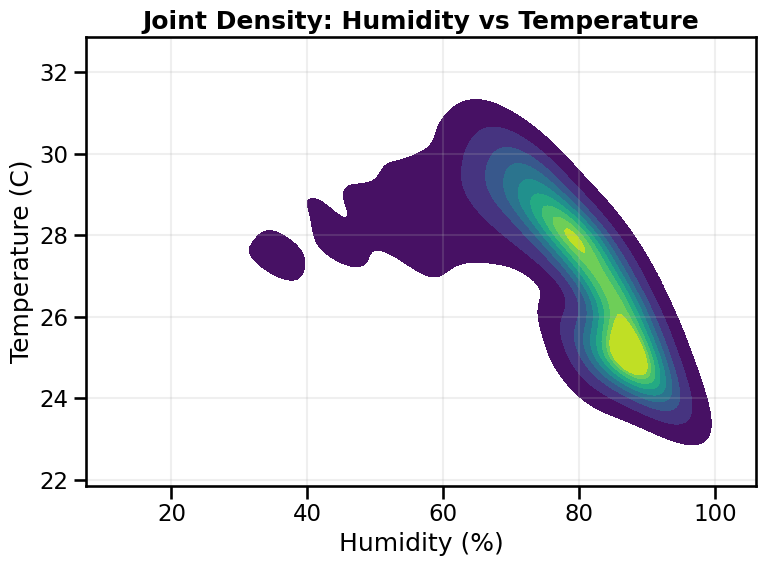

In [10]:

# 4) Joint density: temperature vs humidity
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='humidity_pct', y='temperature_c', fill=True, cmap='viridis', thresh=0.05)
plt.title('Joint Density: Humidity vs Temperature', fontweight='bold')
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (C)')
plt.grid(alpha=0.2)
save_current_fig('joint_density_humidity_temp.png')
plt.show()